In [ ]:
import phaseco as pc
import scipy.io as sio
import os
import numpy as np
from scipy.signal import get_window
from scipy.fft import rfftfreq, rfft
import matplotlib.pyplot as plt
from collections import defaultdict

In [ ]:


dir_data = r"C:\Users\setht\Dropbox\Citadel\GitHub\phase_coherence\data\vaclav_sim"
dir_oto = r"C:\Users\setht\Dropbox\Citadel\GitHub\otocoherence\scripts"
def get_hpbw(win_type, tau, fs, nfft=None):
    if nfft is None:
        nfft = tau * 8
    win = get_window(win_type, tau)
    win_psd = np.abs(rfft(win, nfft)) ** 2
    target = win_psd[0] / 2

    idx = np.where(win_psd <= target)[0][0]
    hpbw = rfftfreq(nfft, 1 / fs)[idx] * 2
    return hpbw
def get_tau_from_bw(hpbw, win_type, fs, nfft=2**25, verbose=False):
    # Get the tau that leads to a window with hpbw closest to the target

    # Exponential search for an upper bound
    lo = 2
    hi = 8
    if verbose:
        print(f"Initializing exponential search for upper bound;")
        print(f"Lower bound is tau={lo}")
        print(f"Testing {hi}:")
    while get_hpbw(win_type, tau=hi, fs=fs, nfft=nfft) > hpbw:
        lo = hi
        hi *= 2
        if verbose:
            print(f"Too small!")
            print(f"Testing {hi}:")
    if verbose:
        print(f"Found upper bound: {hi}")
        print(f"Initializing binary search")
    # Binary search between lo and hi until they are neighbors
    while hi - lo > 1:
        mid = (lo + hi + 1) // 2
        if verbose:
            print(f"[{lo}, {hi}] --- testing {mid}")
        mid_hpwb = get_hpbw(win_type, tau=mid, fs=fs, nfft=nfft)
        if mid_hpwb == hpbw:
            return mid_hpwb
        elif mid_hpwb > hpbw:
            lo = mid
        else:
            hi = mid
    if verbose:
        print(f"Now we're down to [{lo}, {hi}]")
    lo_hpbw = get_hpbw(win_type, tau=lo, fs=fs, nfft=nfft)
    hi_hpbw = get_hpbw(win_type, tau=hi, fs=fs, nfft=nfft)
    # Check which is closer
    if np.abs(hi_hpbw - hpbw) < np.abs(hpbw - lo_hpbw):
        tau = hi
        hpbw = hi_hpbw
    else:
        tau = lo
        hpbw = lo_hpbw
    if verbose:
        print(f"Final answer: {tau} for HPBW={hpbw:.5g}")
    return tau, hpbw


In [ ]:
fn_wf1 = r"longMCsoaeLinL1_20dBdiff100dB_InpN1InpYN0gain85R1rs43.mat"
fn_wf2 = r"longMCsoaeLinL1_20dBdiff100dB_InpN1InpYN0gain85R1rs45.mat"
fn_wfs = [fn_wf1, fn_wf2]
f_peaks = [970, 1067, 1157, 1241, 1343, 1439, 1520, 1652, 1755, 1884, 1974, 2079, 2145, 2244, 2349, 2488, 2635, 2761, 2872, 3019]
win_type = 'flattop'
meths = [{'method':'rho', 'win_type':win_type, 'rho':1.0}, {'method':'static', 'win_type':win_type}]
bw = 50
fs = 40000
# tau, _ = get_tau_from_bw(bw, win_type, fs, verbose=True)
tau = 2980


In [49]:
xis = {'xi_min_s':0.001, 'xi_max_s':0.2,'delta_xi_s':0.001}
hop = int(round(0.01*fs))
# hop = tau
cgrams = defaultdict(dict)
for fn in fn_wfs:
    wf = sio.loadmat(os.path.join(dir_data, fn))['oae'][:, 0]
    for meth in meths:
        cgram_dict = pc.get_colossogram(wf, fs, xis, tau, hop=hop, win_meth=meth, return_dict=True)
        cgrams[fn][meth['method']] = cgram_dict



Calculating colossogram...


100%|██████████| 200/200 [05:10<00:00,  1.55s/it]


Calculating colossogram...


100%|██████████| 200/200 [02:42<00:00,  1.23it/s]


Calculating colossogram...


100%|██████████| 200/200 [05:51<00:00,  1.76s/it]


Calculating colossogram...


100%|██████████| 200/200 [03:21<00:00,  1.01s/it]


In [51]:
import pickle
with open('vaclav_sim_cgrams.pkl', "wb") as file:
    pickle.dump(cgrams, file)

In [ ]:
f, psd = pc.get_welch(wf, fs, tau)
f_peaks = np.array(f_peaks)
f_peaks_idxs = np.argmin(np.abs(f[:, None]-f_peaks[None, :]), 0)
plt.plot(f, 10*np.log10(psd))
plt.scatter(f[f_peaks_idxs], 10*np.log10(psd[f_peaks_idxs]))
plt.xlim(0, 5000)
plt.show()


Initializing fit on 966Hz autocoherence decay...
One peak found in first 51ms of xi, starting fit here
Fitting...
Fit succeeded on first try!
Initializing fit on 1060Hz autocoherence decay...
One peak found in first 51ms of xi, starting fit here
Fitting...
Fit succeeded on first try!
Initializing fit on 1154Hz autocoherence decay...
Two peaks found in first 51ms of xi, starting fit at second one!
Fitting...
Fit succeeded on first try!
Initializing fit on 1235Hz autocoherence decay...
One peak found in first 51ms of xi, starting fit here
Fitting...
Fit succeeded on first try!
Initializing fit on 1342Hz autocoherence decay...
One peak found in first 51ms of xi, starting fit here
Fitting...
Fit succeeded on first try!
Initializing fit on 1436Hz autocoherence decay...
One peak found in first 51ms of xi, starting fit here
Fitting...
Fit succeeded on first try!
Initializing fit on 1517Hz autocoherence decay...
One peak found in first 51ms of xi, starting fit here
Fitting...
Fit succeeded on 

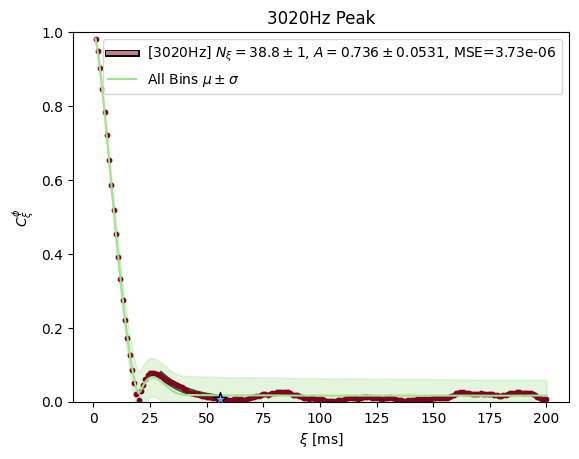

In [52]:
import pandas as pd
dir_results = r"C:\Users\setht\Dropbox\Citadel\GitHub\phase_coherence\plots\vaclav_sim_N_xi"
rows = []
for meth in ['rho', 'static']:
    for fn_wf in fn_wfs:
        cgram = cgrams[fn_wf][meth]
        f = cgram['f']
        for f0 in f_peaks:
            f0_exact = f[np.argmin(np.abs(f0-f))]
            N_xi, N_xi_dict = pc.get_N_xi(cgram, f0_exact)
            plt.close('all')
            pc.plot_N_xi_fit(N_xi_dict)
            dir_plot = os.path.join(dir_results, meth, os.path.splitext(fn_wf)[0])
            os.makedirs(dir_plot, exist_ok=True)
            plt.savefig(os.path.join(dir_plot, f"{f0}.jpg"))
            row = {'meth':meth, 'wf':os.path.splitext(fn_wf)[0], 'f0':f0, 'f0_exact':f0_exact, 'N_xi':N_xi}
            rows.append(row)



df = pd.DataFrame(rows)
df_fn = os.path.join(
    dir_results,
    rf"Sim SOAE N_xi",
)
df.to_excel(
    rf"{df_fn}.xlsx", index=False
)
